# TODO
- check if there's other info in eg the MINI that we are missing...

In [1]:
from utils import *

results_dir = '../results/behavior/'
cos_df = pd.read_csv('../data/narratives/task-embeddings/decision-options_cosines.csv') # add this to decision_trials..

In [ ]:
for sub in incl_subs:
    behavior = load_behavior(sub, neutrals=False)
    choices = behavior[['affil_decision', 'power_decision']].to_numpy(dtype=float)
    choices_by_char = organize_by_character(choices) # list of 5 (12 x 2) arrays

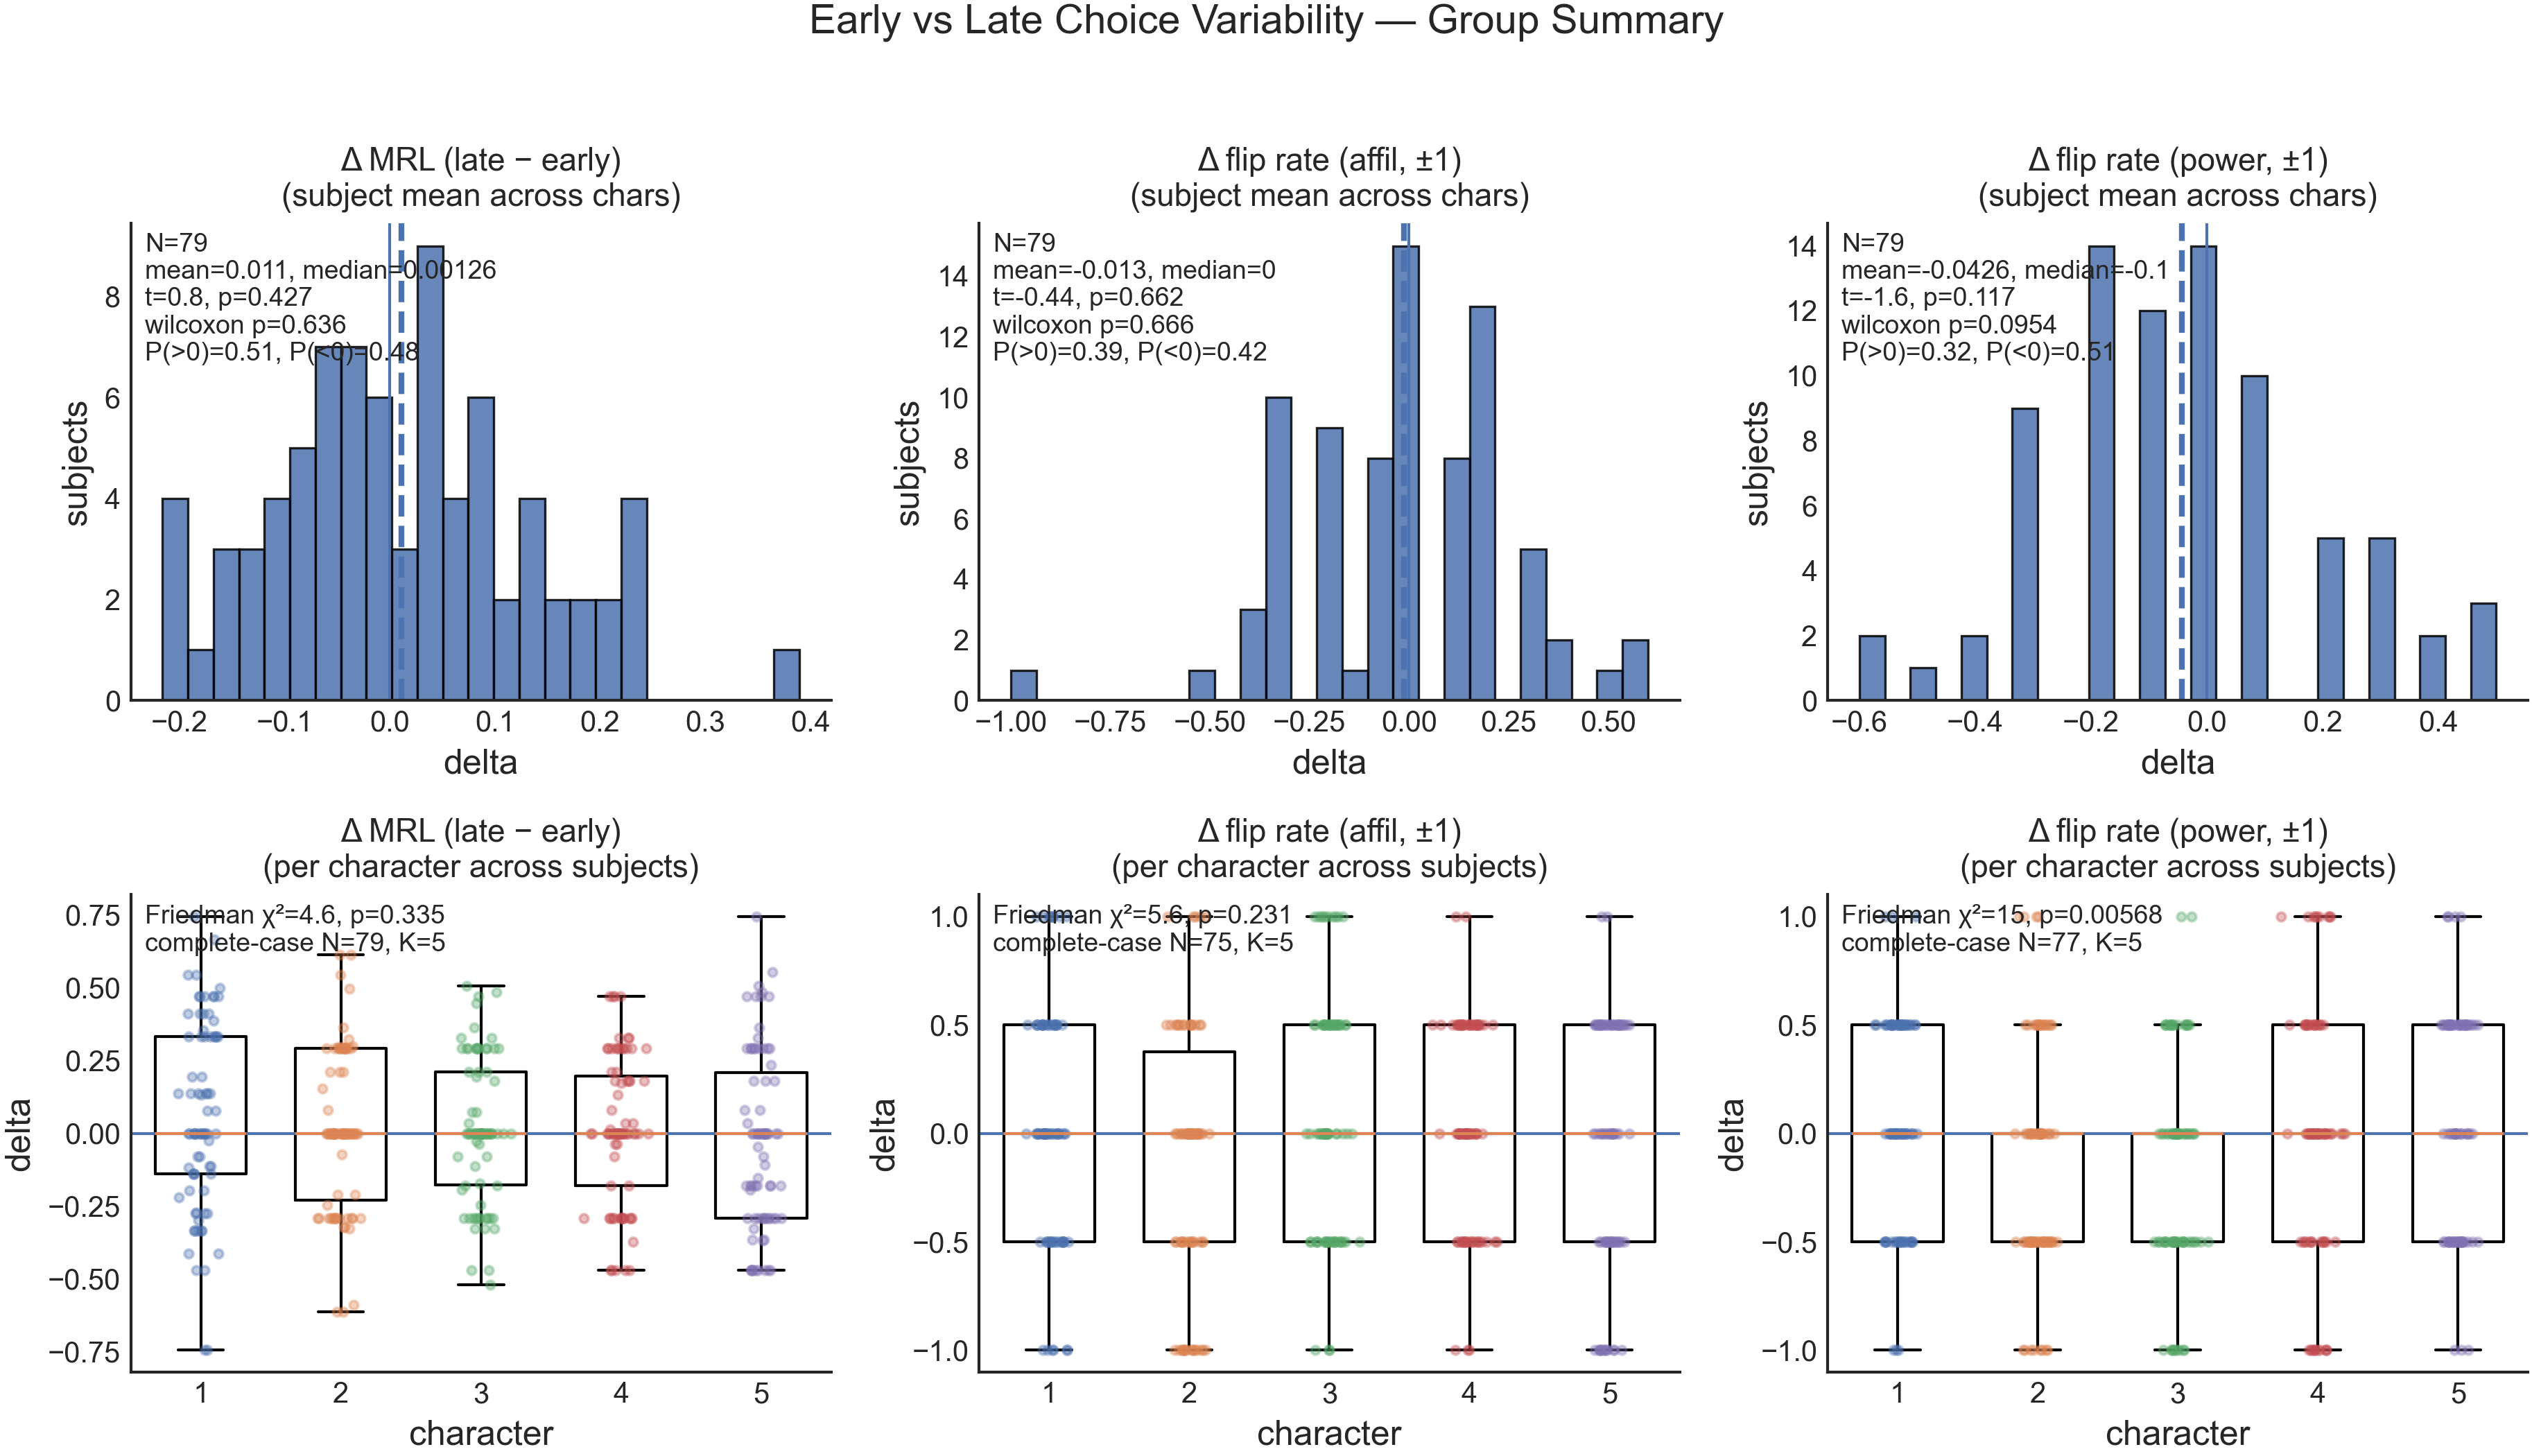

In [10]:
import scipy.stats as st

def compute_and_plot_early_late_variability_all(
    incl_subs,
    *,
    load_behavior,
    organize_by_character,
    neutrals=False,
    char_ids=(1, 2, 3, 4, 5),
    split_nonzero=6,      # early window size in *nonzero* events (per dim, per char)
    n_perm=1500,
    seed=0,
    eps=1e-12,
    figsize=(12.5, 7.0),
    bins=25,
):
    """
    Correct for your task: each trial is ±1 on *one* dimension; the other dimension is 0.

    For flip-rate metrics:
      - isolate a dimension by taking x = X[:, dim]
      - drop zeros: x_nz = x[x != 0]
      - compute flip rate over consecutive nonzero events: mean( x_nz[t] != x_nz[t-1] )
      - split early/late *within the nonzero sequence* (first split_nonzero vs rest)

    Permutation null: circular shifts on the nonzero sequence (preserves local structure).
    Two-sided p: (1 + #{|null| >= |obs|}) / (n_perm + 1)

    Returns:
      df_char_all: subject x character with deltas + p-values
      df_sub_all : subject with mean deltas across characters + tests
      fig        : 2x3 panel plot
    """
    # ---------------------- helpers

    def _circshift_1d(x, k):
        x = np.asarray(x)
        n = x.size
        if n == 0:
            return x
        k = int(k) % n
        if k == 0:
            return x
        return np.r_[x[-k:], x[:-k]]

    def _flip_rate_pm1(x_1d):
        """
        x_1d should be ±1 only (no zeros). Returns flip probability across consecutive events.
        """
        x = np.asarray(x_1d, float)
        x = x[np.isfinite(x)]
        if x.size < 2:
            return np.nan
        # treat any non-±1 as invalid
        m = (x == 1) | (x == -1)
        x = x[m]
        if x.size < 2:
            return np.nan
        return float(np.mean(x[1:] != x[:-1]))

    def _delta_flip_for_dim(X_2d, dim_idx):
        """
        Compute delta flip (late - early) within the nonzero sequence on one dimension.
        """
        x = np.asarray(X_2d, float)[:, dim_idx]
        x = x[np.isfinite(x)]
        x_nz = x[x != 0]      # <-- KEY FIX
        if x_nz.size < 4:     # need at least 2 in each window to define flips robustly
            return np.nan, x_nz

        s = int(split_nonzero)
        # if you have fewer than split_nonzero, define early as first half
        if x_nz.size <= s + 1:
            s = x_nz.size // 2

        if s < 2 or (x_nz.size - s) < 2:
            return np.nan, x_nz

        f_e = _flip_rate_pm1(x_nz[:s])
        f_l = _flip_rate_pm1(x_nz[s:])
        if not np.isfinite(f_e) or not np.isfinite(f_l):
            return np.nan, x_nz
        return float(f_l - f_e), x_nz

    def _unit_rows(X):
        X = np.asarray(X, float)
        m = np.isfinite(X).all(axis=1)
        X = X[m]
        if X.shape[0] == 0:
            return X
        r = np.linalg.norm(X, axis=1)
        U = np.full_like(X, np.nan, float)
        ok = r > eps
        U[ok] = X[ok] / r[ok, None]
        return U

    def _mrl(U):
        U = np.asarray(U, float)
        m = np.isfinite(U).all(axis=1)
        U = U[m]
        if U.shape[0] < 2:
            return np.nan
        return float(np.linalg.norm(U.mean(axis=0)))

    def _delta_mrl(X):
        X = np.asarray(X, float)
        m = np.isfinite(X).all(axis=1)
        X = X[m]
        if X.shape[0] < 4:
            return np.nan
        # keep this as "first 6 trials vs last 6 trials" in the original 12-trial sequence
        # (this is meaningful for axis-choice variability across dims)
        s = min(6, X.shape[0] // 2)
        early, late = X[:s], X[s:]
        mrl_e = _mrl(_unit_rows(early))
        mrl_l = _mrl(_unit_rows(late))
        if not np.isfinite(mrl_e) or not np.isfinite(mrl_l):
            return np.nan
        return float(mrl_l - mrl_e)

    def _perm_pval(obs, null):
        obs = float(obs)
        null = np.asarray(null, float)
        null = null[np.isfinite(null)]
        if not np.isfinite(obs) or null.size == 0:
            return np.nan
        return float((1.0 + np.sum(np.abs(null) >= abs(obs))) / (null.size + 1.0))

    def _one_sample_tests(x):
        x = np.asarray(x, float)
        x = x[np.isfinite(x)]
        out = dict(n=int(x.size), mean=np.nan, median=np.nan, t_p=np.nan, w_p=np.nan, t_stat=np.nan)
        if x.size < 3:
            return out
        out["mean"] = float(np.mean(x))
        out["median"] = float(np.median(x))
        t = st.ttest_1samp(x, 0.0, nan_policy="omit")
        out["t_stat"] = float(t.statistic)
        out["t_p"] = float(t.pvalue)
        try:
            w = st.wilcoxon(x, zero_method="wilcox", alternative="two-sided")
            out["w_p"] = float(w.pvalue)
        except Exception:
            pass
        return out

    def _friedman_across_chars(df_char, metric, sub_col="sub_id", char_col="character"):
        wide = df_char.pivot_table(index=sub_col, columns=char_col, values=metric, aggfunc="mean")
        wide = wide.dropna(axis=0, how="any")
        if wide.shape[0] < 5 or wide.shape[1] < 3:
            return dict(stat=np.nan, p=np.nan, n_sub=int(wide.shape[0]), n_char=int(wide.shape[1]))
        arrays = [wide[c].to_numpy(float) for c in wide.columns]
        stat, p = st.friedmanchisquare(*arrays)
        return dict(stat=float(stat), p=float(p), n_sub=int(wide.shape[0]), n_char=int(wide.shape[1]))

    # ---------------------- compute across subjects
    char_rows = []
    sub_rows = []

    for sub in incl_subs:
        behavior = load_behavior(sub, neutrals=neutrals)
        if behavior is None or len(behavior) == 0:
            continue
        if not {"affil_decision", "power_decision"}.issubset(behavior.columns):
            continue

        choices = behavior[["affil_decision", "power_decision"]].to_numpy(dtype=float)

        # optional: if (0,0) encodes missing responses, uncomment:
        # miss = (choices[:,0] == 0) & (choices[:,1] == 0)
        # choices = choices.copy()
        # choices[miss] = np.nan

        choices_by_char = organize_by_character(choices)
        if choices_by_char is None or len(choices_by_char) == 0:
            continue

        # reproducible per-subject RNG
        sub_seed = (abs(hash((str(sub), int(seed)))) % (2**32 - 1))
        rng = np.random.default_rng(sub_seed)

        per_char = []

        for cid, X in zip(list(char_ids), choices_by_char):
            X = np.asarray(X, float)
            if X.ndim != 2 or X.shape[1] != 2:
                continue

            # -------- MRL delta (uses full 2D choices; OK given axis-choice structure)
            obs_mrl = _delta_mrl(X)

            # -------- flip deltas computed per dimension on nonzero sequences
            obs_fa, x_nz_a = _delta_flip_for_dim(X, dim_idx=0)   # affil
            obs_fp, x_nz_p = _delta_flip_for_dim(X, dim_idx=1)   # power

            # permutation nulls (do circular shifts on the nonzero event sequence)
            null_mrl = np.full(int(n_perm), np.nan, float)
            null_fa  = np.full(int(n_perm), np.nan, float)
            null_fp  = np.full(int(n_perm), np.nan, float)

            # MRL perm: circular shift on full 12-trial 2D sequence (preserves axis pattern)
            if np.isfinite(obs_mrl) and X.shape[0] >= 4:
                T = X.shape[0]
                shifts = rng.integers(0, T, size=int(n_perm))
                for i, k in enumerate(shifts):
                    Xp = np.vstack([X[-k:], X[:-k]]) if k % T != 0 else X
                    null_mrl[i] = _delta_mrl(Xp)

            # flip perms: operate on the NONZERO sequence itself
            if np.isfinite(obs_fa) and x_nz_a.size >= 4:
                na = x_nz_a.size
                shifts = rng.integers(0, na, size=int(n_perm))
                for i, k in enumerate(shifts):
                    xa = _circshift_1d(x_nz_a, k)
                    # recompute delta with same split logic
                    s = min(int(split_nonzero), xa.size // 2)
                    if s >= 2 and (xa.size - s) >= 2:
                        null_fa[i] = _flip_rate_pm1(xa[s:]) - _flip_rate_pm1(xa[:s])

            if np.isfinite(obs_fp) and x_nz_p.size >= 4:
                npow = x_nz_p.size
                shifts = rng.integers(0, npow, size=int(n_perm))
                for i, k in enumerate(shifts):
                    xp = _circshift_1d(x_nz_p, k)
                    s = min(int(split_nonzero), xp.size // 2)
                    if s >= 2 and (xp.size - s) >= 2:
                        null_fp[i] = _flip_rate_pm1(xp[s:]) - _flip_rate_pm1(xp[:s])

            row = dict(
                sub_id=sub,
                character=cid,
                n_trials=int(X.shape[0]),

                delta_mrl=obs_mrl,
                p_delta_mrl=_perm_pval(obs_mrl, null_mrl),

                delta_flip_affil=obs_fa,
                p_delta_flip_affil=_perm_pval(obs_fa, null_fa),

                delta_flip_power=obs_fp,
                p_delta_flip_power=_perm_pval(obs_fp, null_fp),

                n_affil_nonzero=int(x_nz_a.size),
                n_power_nonzero=int(x_nz_p.size),
            )
            char_rows.append(row)
            per_char.append(row)

        if len(per_char) == 0:
            continue

        df_tmp = pd.DataFrame(per_char)
        sub_rows.append(dict(
            sub_id=sub,
            n_char=int(df_tmp.shape[0]),

            delta_mrl_mean=float(np.nanmean(df_tmp["delta_mrl"].to_numpy(float))),
            delta_flip_affil_mean=float(np.nanmean(df_tmp["delta_flip_affil"].to_numpy(float))),
            delta_flip_power_mean=float(np.nanmean(df_tmp["delta_flip_power"].to_numpy(float))),

            # descriptive: fraction of chars with enough nonzero events
            frac_chars_affil_ok=float(np.mean(df_tmp["n_affil_nonzero"].to_numpy(int) >= 4)),
            frac_chars_power_ok=float(np.mean(df_tmp["n_power_nonzero"].to_numpy(int) >= 4)),
        ))

    df_char_all = pd.DataFrame(char_rows)
    df_sub_all  = pd.DataFrame(sub_rows)

    if df_sub_all.empty or df_char_all.empty:
        raise ValueError("No data computed. Check load_behavior/organize_by_character outputs.")

    # ---------------------- plotting
    metrics = [
        ("delta_mrl_mean", "Δ MRL (late − early)", "delta_mrl"),
        ("delta_flip_affil_mean", "Δ flip rate (affil, ±1)", "delta_flip_affil"),
        ("delta_flip_power_mean", "Δ flip rate (power, ±1)", "delta_flip_power"),
    ]

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    for j, (sub_metric, title, char_metric) in enumerate(metrics):
        # top row: subject-level mean delta distribution
        ax = axs[0, j]
        x = pd.to_numeric(df_sub_all[sub_metric], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]
        tests = _one_sample_tests(x)

        ax.hist(x, bins=bins, edgecolor="black", alpha=0.85)
        ax.axvline(0, linewidth=1)
        if np.isfinite(tests["mean"]):
            ax.axvline(tests["mean"], linestyle="--", linewidth=2)

        prop_pos = float(np.mean(x > 0)) if x.size else np.nan
        prop_neg = float(np.mean(x < 0)) if x.size else np.nan

        ax.text(
            0.02, 0.98,
            f"N={tests['n']}\nmean={tests['mean']:.3g}, median={tests['median']:.3g}\n"
            f"t={tests['t_stat']:.2g}, p={tests['t_p']:.3g}\n"
            f"wilcoxon p={tests['w_p']:.3g}\n"
            f"P(>0)={prop_pos:.2f}, P(<0)={prop_neg:.2f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9
        )
        ax.set_title(f"{title}\n(subject mean across chars)", fontsize=11)
        ax.set_xlabel("delta")
        ax.set_ylabel("subjects")

        # bottom row: per-character distributions across subjects (robust to missing chars)
        ax2 = axs[1, j]
        sub = df_char_all[["sub_id", "character", char_metric]].copy()
        sub[char_metric] = pd.to_numeric(sub[char_metric], errors="coerce")
        sub = sub[np.isfinite(sub[char_metric].to_numpy(float))]

        chars_all = sorted(pd.unique(sub["character"]))
        pairs = []
        for c in chars_all:
            y = sub.loc[sub["character"] == c, char_metric].to_numpy(float)
            y = y[np.isfinite(y)]
            if y.size > 0:
                pairs.append((c, y))

        if len(pairs) == 0:
            ax2.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax2.transAxes)
            ax2.set_axis_off()
            continue

        chars = [c for c, _ in pairs]
        y_by_char = [y for _, y in pairs]

        ax2.boxplot(y_by_char, labels=[str(c) for c in chars], showfliers=False, widths=0.65)

        rngj = np.random.default_rng(0)
        for i, y in enumerate(y_by_char, start=1):
            jj = rngj.normal(0, 0.07, size=len(y))
            ax2.plot(np.full_like(y, i, dtype=float) + jj, y, "o", alpha=0.35, markersize=3)

        ax2.axhline(0, linewidth=1)

        fr = _friedman_across_chars(df_char_all, char_metric)
        ax2.text(
            0.02, 0.98,
            f"Friedman χ²={fr['stat']:.2g}, p={fr['p']:.3g}\ncomplete-case N={fr['n_sub']}, K={fr['n_char']}",
            transform=ax2.transAxes, va="top", ha="left", fontsize=9
        )
        ax2.set_title(f"{title}\n(per character across subjects)", fontsize=11)
        ax2.set_xlabel("character")
        ax2.set_ylabel("delta")

    fig.suptitle("Early vs Late Choice Variability — Group Summary", y=1.02, fontsize=14)
    fig.tight_layout()

    return df_char_all, df_sub_all, fig

df_char_all, df_sub_all, fig = compute_and_plot_early_late_variability_all(
    incl_subs,
    load_behavior=load_behavior,
    organize_by_character=organize_by_character,
    neutrals=False,
    char_ids=(1, 2, 3, 4, 5),
    split_nonzero=6,   # early = first 6 nonzero events on that axis; late = remaining
    n_perm=1500,
    seed=0,
)
plt.show()

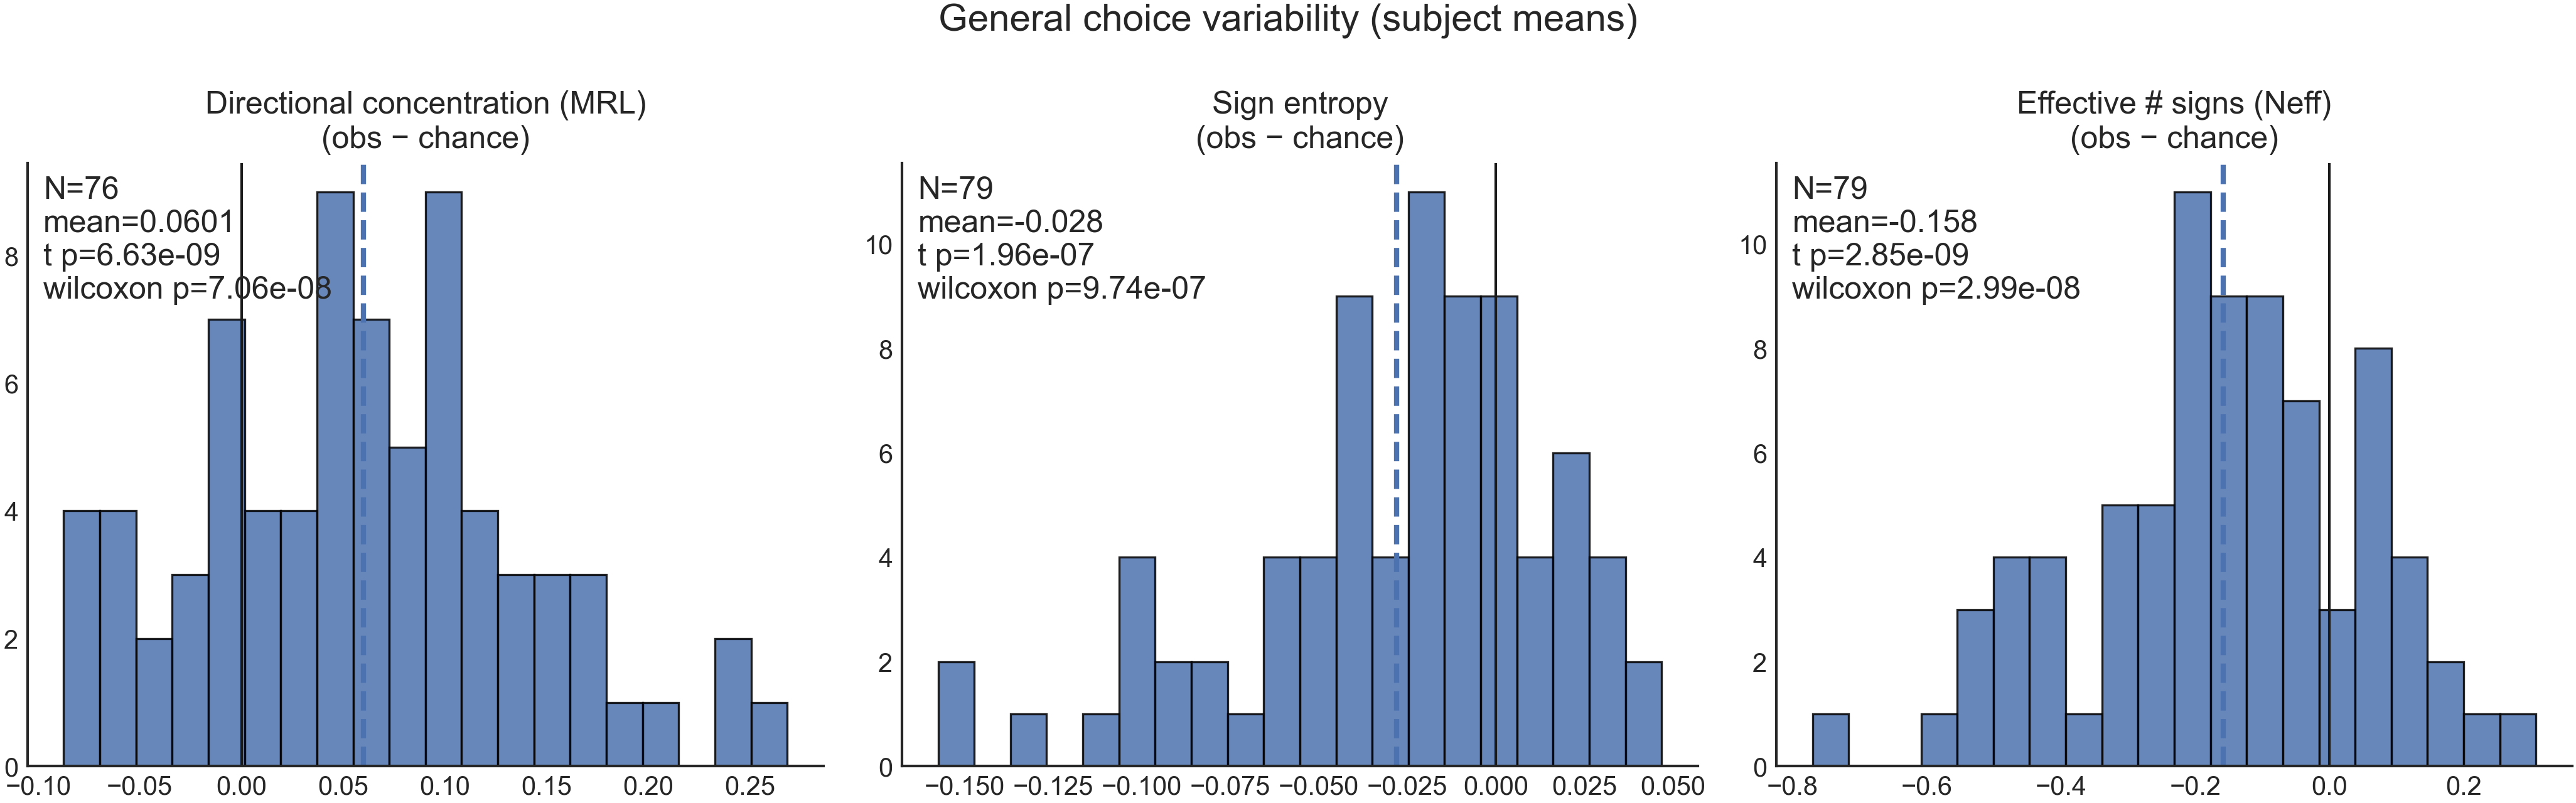

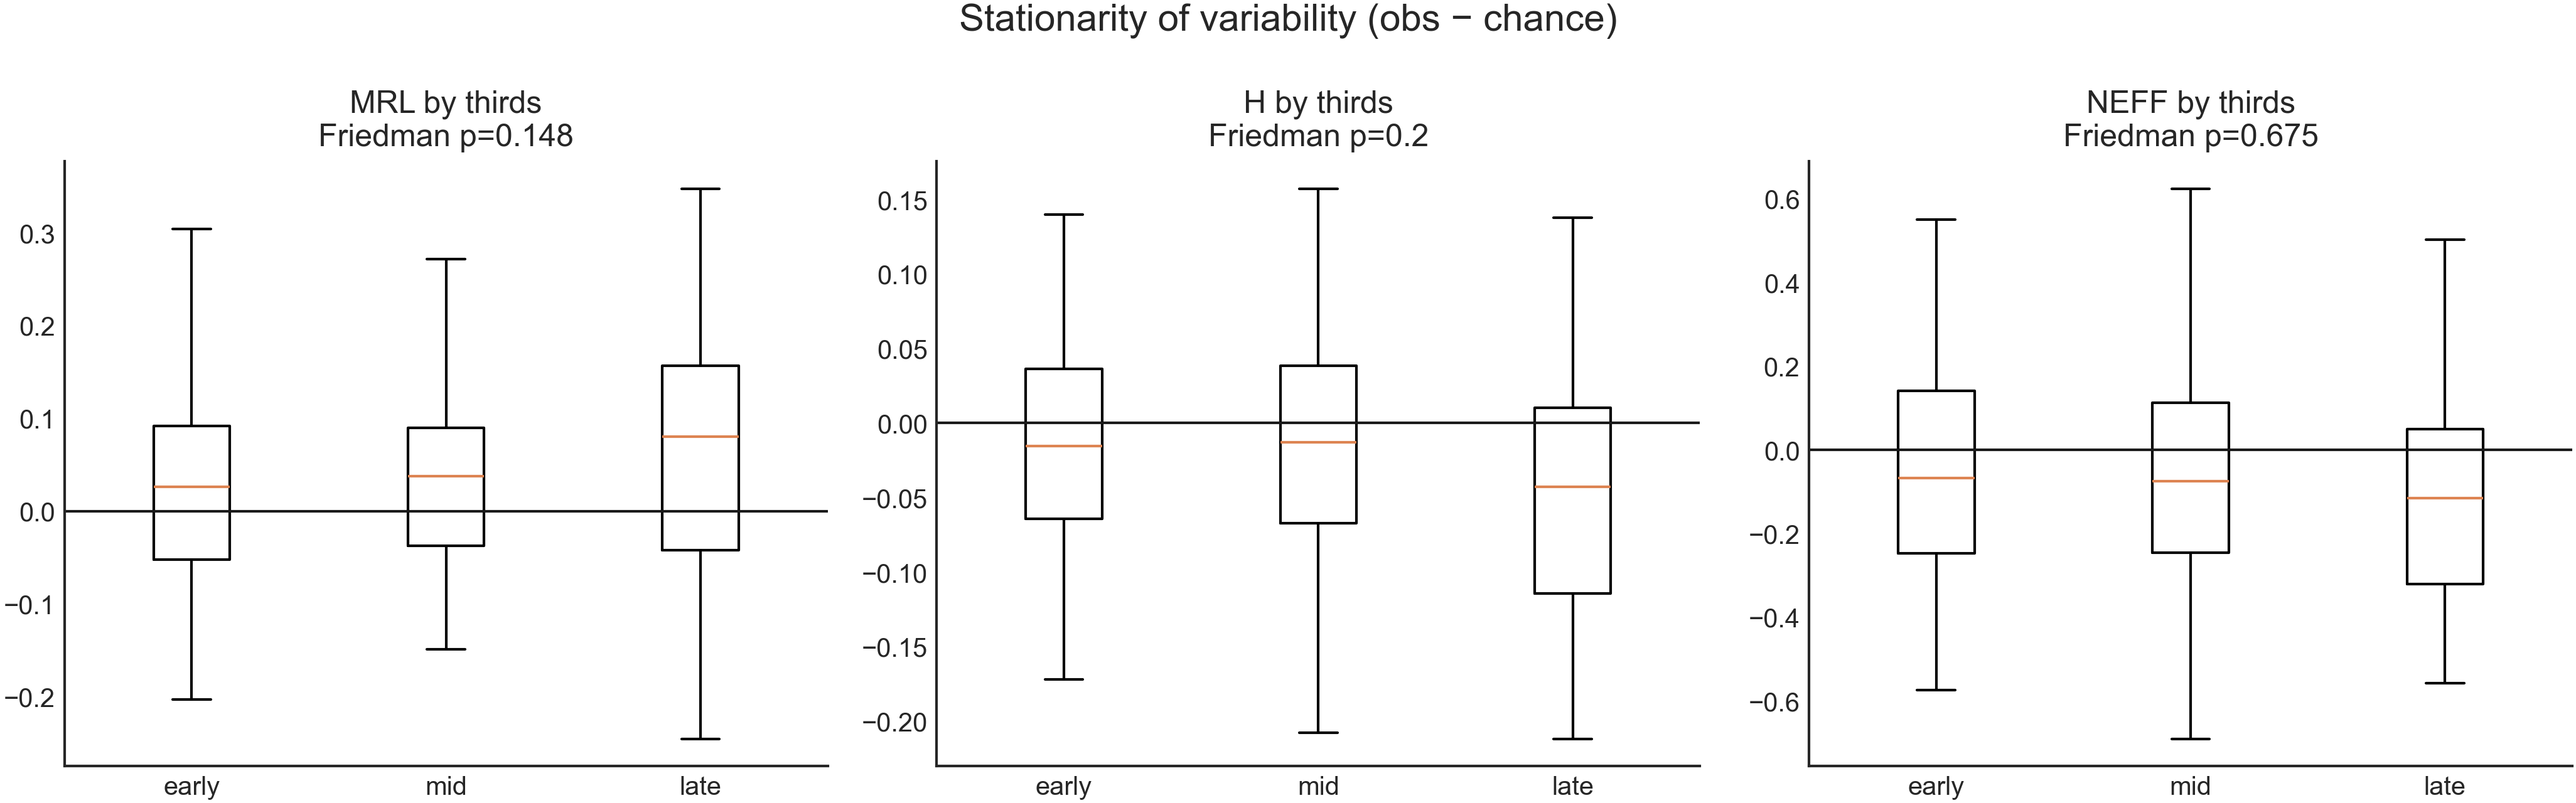

In [11]:
import scipy.stats as st

def compute_and_plot_choice_variability_all(
    incl_subs,
    *,
    load_behavior,
    organize_by_character,
    neutrals=False,
    char_ids=(1, 2, 3, 4, 5),
    n_null=200,
    seed=0,
    figsize=(14, 9),
):
    """
    General choice variability + early/mid/late thirds.
    Correct for task structure: dimension fixed, sign is ±1.

    Returns
    -------
    df_char_all : subject × character
    df_sub_all  : subject-level aggregates
    figs        : dict of matplotlib figures
    """

    rng = np.random.default_rng(seed)

    # ---------- helpers

    def split_thirds(X):
        T = X.shape[0]
        return X[:4], X[4:8], X[8:12]

    def mrl_2d(X):
        X = X[np.isfinite(X).all(axis=1)]
        if X.shape[0] < 2:
            return np.nan
        U = X / np.linalg.norm(X, axis=1, keepdims=True)
        return float(np.linalg.norm(U.mean(axis=0)))

    def sign_entropy_and_neff(X):
        # X is (T,2), only one nonzero per row
        labs = []
        for a, p in X:
            if a == 1: labs.append("A+")
            elif a == -1: labs.append("A-")
            elif p == 1: labs.append("P+")
            elif p == -1: labs.append("P-")
        if len(labs) < 2:
            return np.nan, np.nan
        vals, cnts = np.unique(labs, return_counts=True)
        p = cnts / cnts.sum()
        H = -np.sum(p * np.log(p))
        Hn = H / np.log(4)          # normalized entropy
        neff = 1.0 / np.sum(p**2)
        return float(Hn), float(neff)

    def null_sample(X):
        # preserve dimension schedule, randomize sign
        Xn = X.copy()
        for i in range(X.shape[0]):
            if X[i, 0] != 0:
                Xn[i, 0] = rng.choice([-1, 1])
            elif X[i, 1] != 0:
                Xn[i, 1] = rng.choice([-1, 1])
        return Xn

    # ---------- compute

    char_rows = []
    sub_rows = []

    for sub in incl_subs:
        beh = load_behavior(sub, neutrals=neutrals)
        if beh is None or beh.empty:
            continue

        choices = beh[["affil_decision", "power_decision"]].to_numpy(float)
        choices_by_char = organize_by_character(choices)

        per_char = []

        for cid, X in zip(char_ids, choices_by_char):
            if X.shape[0] < 12:
                continue

            thirds = split_thirds(X)

            # observed
            obs = {
                "mrl_all": mrl_2d(X),
                "H_all": sign_entropy_and_neff(X)[0],
                "neff_all": sign_entropy_and_neff(X)[1],
            }

            for i, W in enumerate(thirds):
                obs[f"mrl_t{i+1}"] = mrl_2d(W)
                H, ne = sign_entropy_and_neff(W)
                obs[f"H_t{i+1}"] = H
                obs[f"neff_t{i+1}"] = ne

            # null
            null = {k: [] for k in obs}
            for _ in range(n_null):
                Xn = null_sample(X)
                thirds_n = split_thirds(Xn)
                null["mrl_all"].append(mrl_2d(Xn))
                Hn, nen = sign_entropy_and_neff(Xn)
                null["H_all"].append(Hn)
                null["neff_all"].append(nen)
                for i, Wn in enumerate(thirds_n):
                    null[f"mrl_t{i+1}"].append(mrl_2d(Wn))
                    Hn, nen = sign_entropy_and_neff(Wn)
                    null[f"H_t{i+1}"].append(Hn)
                    null[f"neff_t{i+1}"].append(nen)

            row = dict(sub_id=sub, character=cid)
            for k in obs:
                row[k] = obs[k]
                row[k + "_chance"] = np.nanmean(null[k])
                row[k + "_diff"] = obs[k] - row[k + "_chance"]
            char_rows.append(row)
            per_char.append(row)

        if not per_char:
            continue

        df_tmp = pd.DataFrame(per_char)
        sub_row = dict(sub_id=sub)
        for k in ["mrl_all", "H_all", "neff_all"]:
            sub_row[k + "_mean"] = df_tmp[k].mean()
            sub_row[k + "_diff_mean"] = df_tmp[k + "_diff"].mean()
        for i in range(1, 4):
            for k in ["mrl", "H", "neff"]:
                sub_row[f"{k}_t{i}_mean"] = df_tmp[f"{k}_t{i}"].mean()
                sub_row[f"{k}_t{i}_diff_mean"] = df_tmp[f"{k}_t{i}_diff"].mean()
        sub_rows.append(sub_row)

    df_char_all = pd.DataFrame(char_rows)
    df_sub_all = pd.DataFrame(sub_rows)

    # ---------- plotting

    figs = {}

    def plot_hist(ax, x, title):
        x = x[np.isfinite(x)]
        ax.hist(x, bins=20, edgecolor="black", alpha=0.85)
        ax.axvline(0, color="k", lw=1)
        mu = x.mean()
        ax.axvline(mu, ls="--", lw=2)
        t = st.ttest_1samp(x, 0.0)
        w = st.wilcoxon(x)
        ax.set_title(title)
        ax.text(
            0.02, 0.98,
            f"N={len(x)}\nmean={mu:.3g}\n"
            f"t p={t.pvalue:.3g}\nwilcoxon p={w.pvalue:.3g}",
            transform=ax.transAxes, va="top"
        )

    # ---- Figure 1: general variability
    fig1, axs = plt.subplots(1, 3, figsize=(figsize[0], figsize[1]/2))
    plot_hist(axs[0], df_sub_all["mrl_all_diff_mean"].values,
              "Directional concentration (MRL)\n(obs − chance)")
    plot_hist(axs[1], df_sub_all["H_all_diff_mean"].values,
              "Sign entropy\n(obs − chance)")
    plot_hist(axs[2], df_sub_all["neff_all_diff_mean"].values,
              "Effective # signs (Neff)\n(obs − chance)")
    fig1.suptitle("General choice variability (subject means)")
    fig1.tight_layout()
    figs["global"] = fig1

    # ---- Figure 2: early / mid / late
    fig2, axs = plt.subplots(1, 3, figsize=(figsize[0], figsize[1]/2))
    for j, k in enumerate(["mrl", "H", "neff"]):
        Y = np.vstack([
            df_sub_all[f"{k}_t1_diff_mean"],
            df_sub_all[f"{k}_t2_diff_mean"],
            df_sub_all[f"{k}_t3_diff_mean"],
        ]).T
        ax = axs[j]
        ax.boxplot(Y, labels=["early", "mid", "late"], showfliers=False)
        stat, p = st.friedmanchisquare(Y[:, 0], Y[:, 1], Y[:, 2])
        ax.set_title(f"{k.upper()} by thirds\nFriedman p={p:.3g}")
        ax.axhline(0, color="k", lw=1)
    fig2.suptitle("Stationarity of variability (obs − chance)")
    fig2.tight_layout()
    figs["thirds"] = fig2

    return df_char_all, df_sub_all, figs

df_char_all, df_sub_all, figs = compute_and_plot_choice_variability_all(
    incl_subs,
    load_behavior=load_behavior,
    organize_by_character=organize_by_character,
    neutrals=False,
)

plt.show()

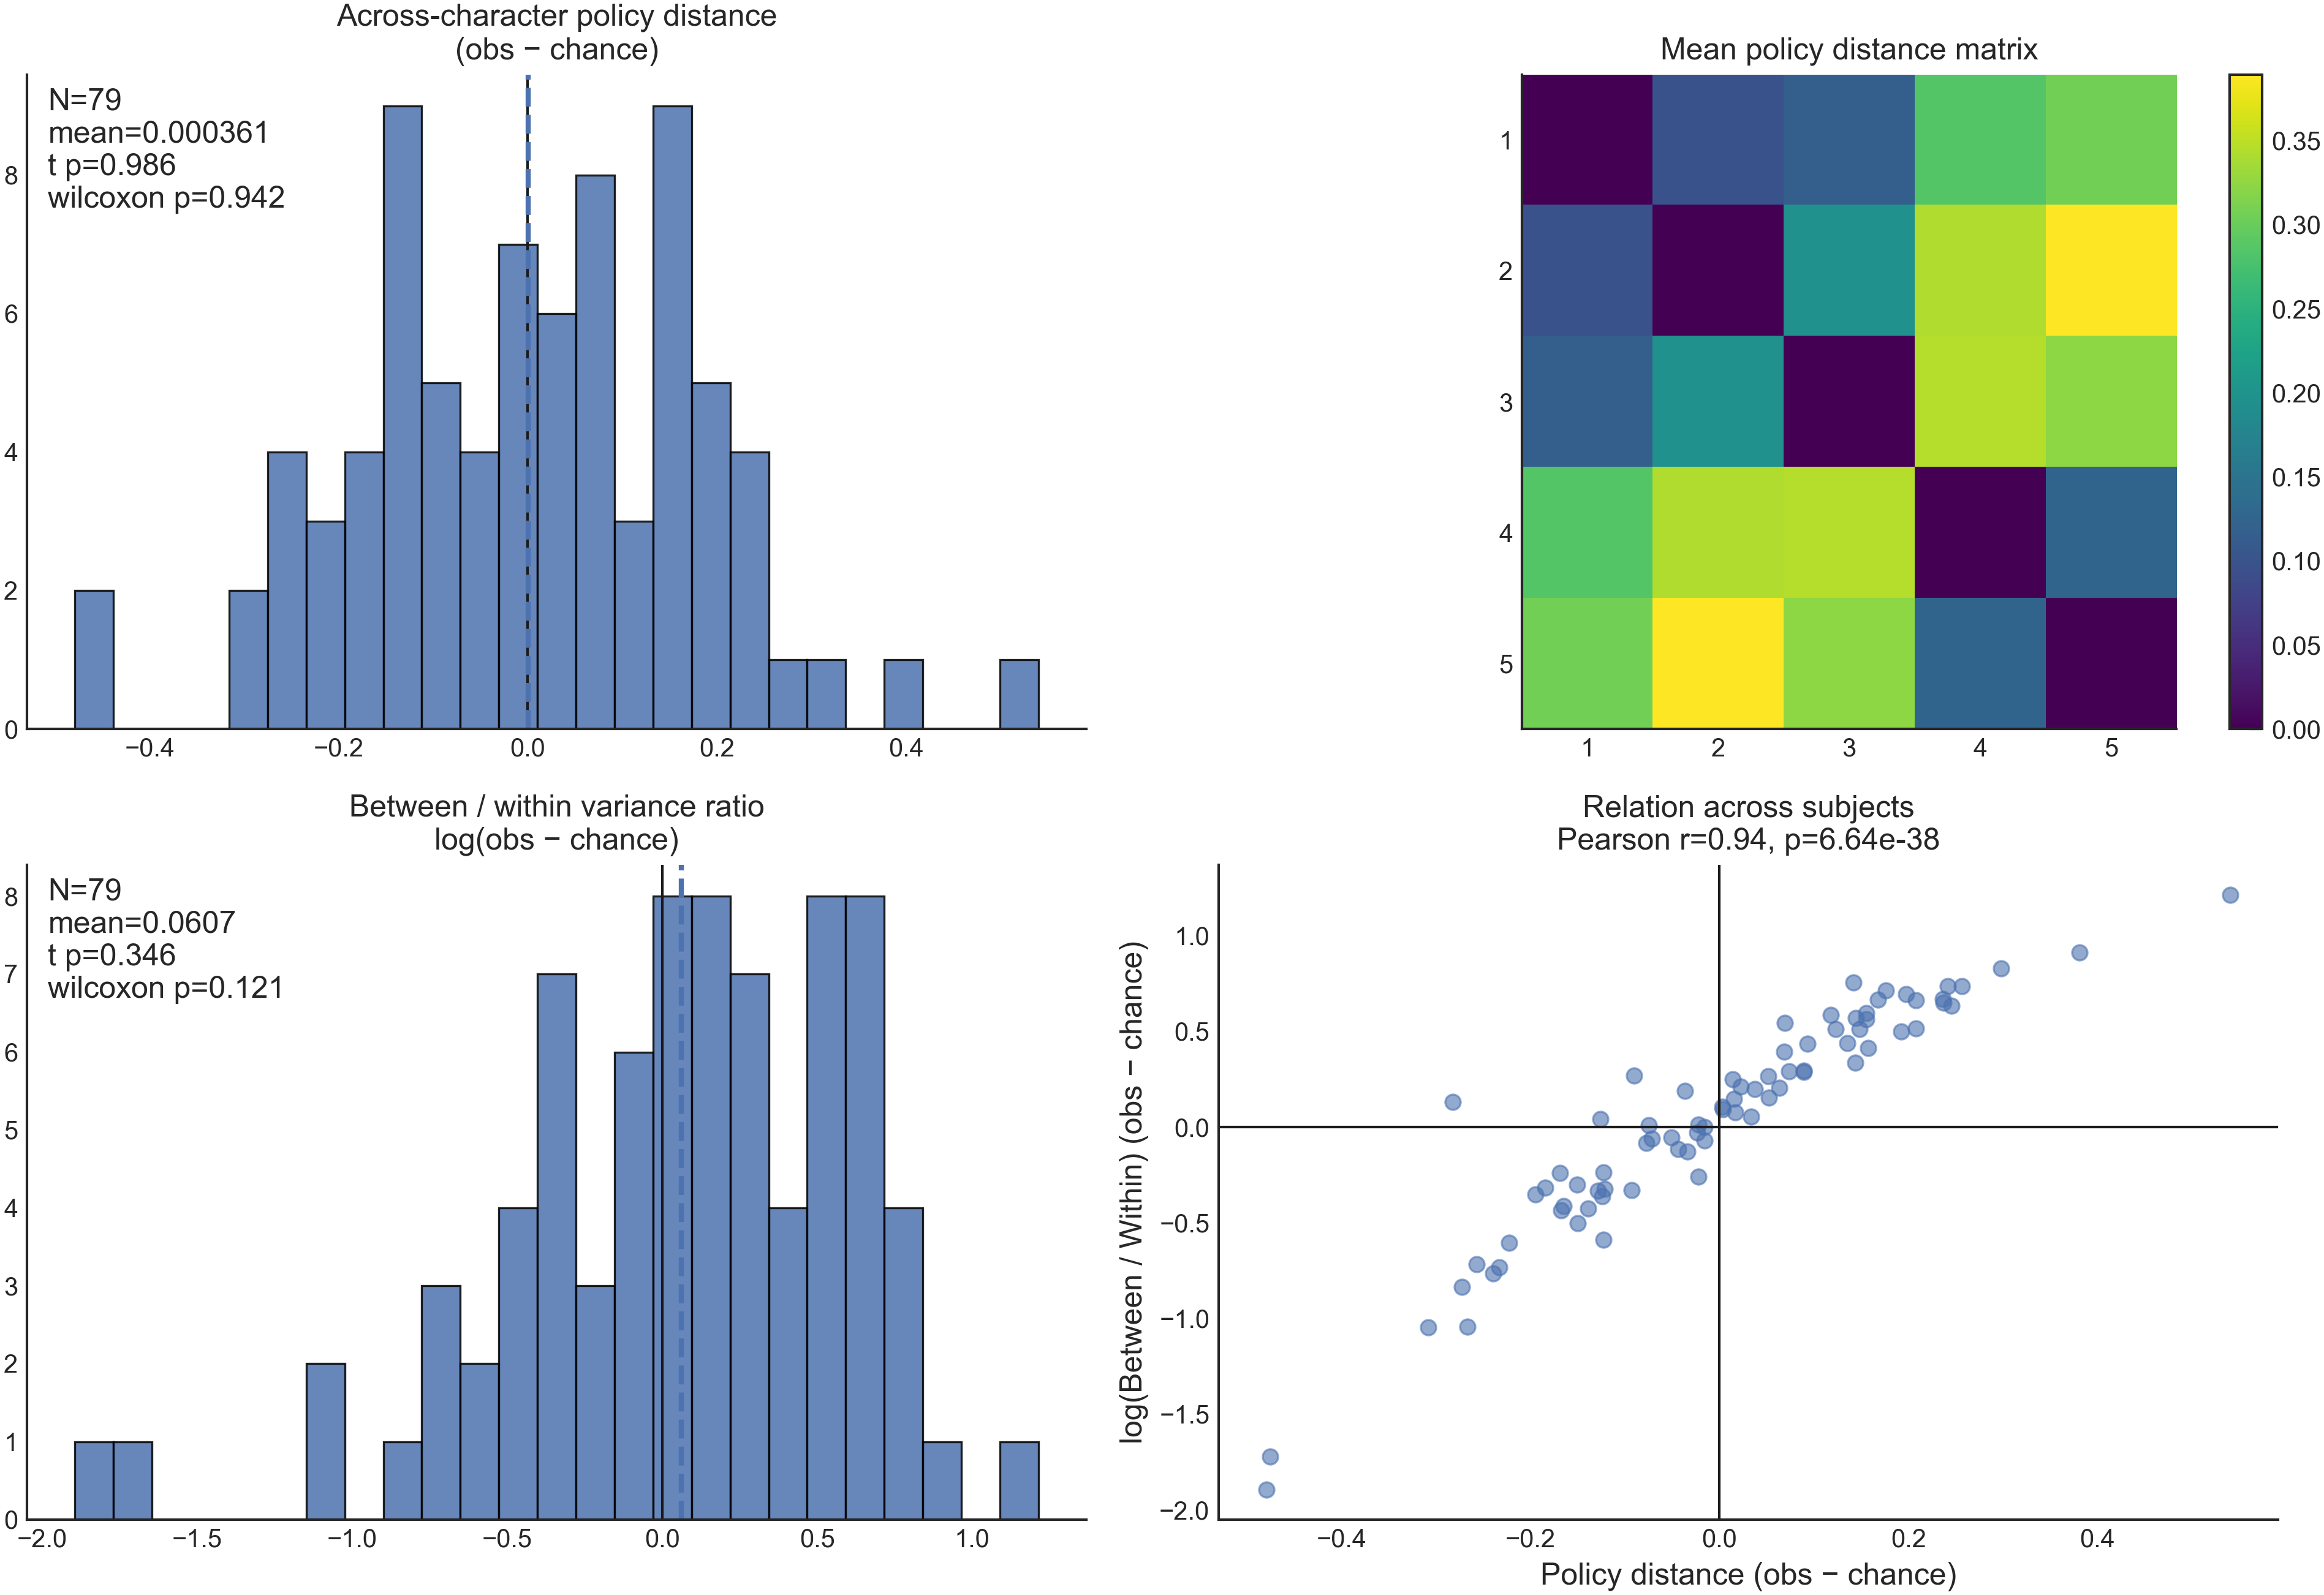

In [12]:
import scipy.stats as st

def analyze_within_across_character_variability(
    incl_subs,
    *,
    load_behavior,
    organize_by_character,
    neutrals=False,
    char_ids=(1, 2, 3, 4, 5),
    n_perm=1000,
    seed=0,
    eps=1e-12,
    figsize=(13, 9),
):
    """
    Metric 4: across-character policy distances
    Metric 5: between / within character variance ratio

    Returns
    -------
    df_char : subject × character policy vectors
    df_sub  : subject-level metrics + permutation p-values
    fig     : annotated matplotlib figure
    """

    rng_global = np.random.default_rng(seed)

    # ---------------- helpers

    def policy_vector(X):
        """Mean ±1 sign per dimension (ignore zeros)."""
        a = X[:, 0]
        p = X[:, 1]
        ma = np.nan if np.all(a == 0) else np.mean(a[a != 0])
        mp = np.nan if np.all(p == 0) else np.mean(p[p != 0])
        return np.array([ma, mp], float)

    def within_variance(X, mu):
        """E[||x||^2] - ||mu||^2 (axis-aligned choices)."""
        X = X[np.isfinite(X).all(axis=1)]
        if X.size == 0:
            return np.nan
        norm2 = np.sum(X * X, axis=1)  # mostly 1
        return float(np.mean(norm2) - np.sum(mu * mu))

    def permute_signs(X, rng):
        Xp = X.copy()
        for i in range(X.shape[0]):
            if X[i, 0] != 0:
                Xp[i, 0] = rng.choice([-1, 1])
                Xp[i, 1] = 0
            elif X[i, 1] != 0:
                Xp[i, 1] = rng.choice([-1, 1])
                Xp[i, 0] = 0
        return Xp

    def perm_p(obs, null):
        null = np.asarray(null)
        m = np.nanmean(null)
        return (1 + np.sum(np.abs(null - m) >= abs(obs - m))) / (len(null) + 1)

    # ---------------- main loop

    char_rows = []
    sub_rows = []

    for sub in incl_subs:
        beh = load_behavior(sub, neutrals=neutrals)
        if beh is None or beh.empty:
            continue

        Xall = beh[["affil_decision", "power_decision"]].to_numpy(float)
        by_char = organize_by_character(Xall)
        if not by_char:
            continue

        rng = np.random.default_rng(abs(hash((sub, seed))) % (2**32))

        # ---- observed
        pis = []
        mus = []
        within_vars = []

        for cid, X in zip(char_ids, by_char):
            pi = policy_vector(X)
            mu = np.nanmean(X, axis=0)
            wv = within_variance(X, mu)

            pis.append(pi)
            mus.append(mu)
            within_vars.append(wv)

            char_rows.append(dict(
                sub_id=sub,
                character=cid,
                bias_affil=pi[0],
                bias_power=pi[1],
            ))

        pis = np.asarray(pis)
        mus = np.asarray(mus)
        within_vars = np.asarray(within_vars)

        # distance matrix
        D = np.linalg.norm(pis[:, None, :] - pis[None, :, :], axis=2)
        off = D[np.triu_indices(len(pis), k=1)]
        mean_dist = np.nanmean(off)

        # variance ratio
        mu_bar = np.nanmean(mus, axis=0)
        var_between = np.nanmean(np.sum((mus - mu_bar) ** 2, axis=1))
        var_within = np.nanmean(within_vars)
        R = var_between / (var_within + eps)
        logR = np.log(R + eps)

        # ---- permutation nulls
        null_dist = []
        null_logR = []

        for _ in range(n_perm):
            pis_n = []
            mus_n = []
            wv_n = []

            for X in by_char:
                Xp = permute_signs(X, rng)
                pis_n.append(policy_vector(Xp))
                mu_n = np.nanmean(Xp, axis=0)
                mus_n.append(mu_n)
                wv_n.append(within_variance(Xp, mu_n))

            pis_n = np.asarray(pis_n)
            mus_n = np.asarray(mus_n)

            Dn = np.linalg.norm(pis_n[:, None, :] - pis_n[None, :, :], axis=2)
            off_n = Dn[np.triu_indices(len(pis_n), k=1)]
            null_dist.append(np.nanmean(off_n))

            mu_bar_n = np.nanmean(mus_n, axis=0)
            vb = np.nanmean(np.sum((mus_n - mu_bar_n) ** 2, axis=1))
            vw = np.nanmean(wv_n)
            null_logR.append(np.log(vb / (vw + eps) + eps))

        null_dist = np.asarray(null_dist)
        null_logR = np.asarray(null_logR)

        sub_rows.append(dict(
            sub_id=sub,
            mean_policy_dist=mean_dist,
            mean_policy_dist_chance=np.nanmean(null_dist),
            mean_policy_dist_diff=mean_dist - np.nanmean(null_dist),
            p_policy_dist=perm_p(mean_dist, null_dist),

            logR=logR,
            logR_chance=np.nanmean(null_logR),
            logR_diff=logR - np.nanmean(null_logR),
            p_logR=perm_p(logR, null_logR),
        ))

    df_char = pd.DataFrame(char_rows)
    df_sub = pd.DataFrame(sub_rows)

    # ---------------- plotting

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    def hist_panel(ax, x, title):
        x = x[np.isfinite(x)]
        ax.hist(x, bins=25, edgecolor="black", alpha=0.85)
        ax.axvline(0, color="k", lw=1)
        m = np.mean(x)
        ax.axvline(m, ls="--", lw=2)
        t = st.ttest_1samp(x, 0.0)
        w = st.wilcoxon(x)
        ax.set_title(title)
        ax.text(
            0.02, 0.98,
            f"N={len(x)}\nmean={m:.3g}\n"
            f"t p={t.pvalue:.3g}\nwilcoxon p={w.pvalue:.3g}",
            transform=ax.transAxes, va="top"
        )

    hist_panel(
        axs[0, 0],
        df_sub["mean_policy_dist_diff"].values,
        "Across-character policy distance\n(obs − chance)",
    )

    hist_panel(
        axs[1, 0],
        df_sub["logR_diff"].values,
        "Between / within variance ratio\nlog(obs − chance)",
    )

    # group-average distance matrix
    piv = df_char.pivot_table(
        index="sub_id", columns="character", values=["bias_affil", "bias_power"]
    )
    pis_mean = np.stack([
        np.nanmean(piv["bias_affil"].values, axis=0),
        np.nanmean(piv["bias_power"].values, axis=0),
    ], axis=1)

    Dm = np.linalg.norm(pis_mean[:, None, :] - pis_mean[None, :, :], axis=2)
    im = axs[0, 1].imshow(Dm, cmap="viridis")
    axs[0, 1].set_title("Mean policy distance matrix")
    axs[0, 1].set_xticks(range(len(char_ids)))
    axs[0, 1].set_yticks(range(len(char_ids)))
    axs[0, 1].set_xticklabels(char_ids)
    axs[0, 1].set_yticklabels(char_ids)
    plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

    # relationship panel
    x = df_sub["mean_policy_dist_diff"].values
    y = df_sub["logR_diff"].values
    axs[1, 1].scatter(x, y, alpha=0.6)
    r, p = st.pearsonr(x, y)
    axs[1, 1].set_xlabel("Policy distance (obs − chance)")
    axs[1, 1].set_ylabel("log(Between / Within) (obs − chance)")
    axs[1, 1].set_title(f"Relation across subjects\nPearson r={r:.2g}, p={p:.3g}")
    axs[1, 1].axhline(0, color="k", lw=1)
    axs[1, 1].axvline(0, color="k", lw=1)

    fig.tight_layout()
    return df_char, df_sub, fig

df_char, df_sub, fig = analyze_within_across_character_variability(
    incl_subs,
    load_behavior=load_behavior,
    organize_by_character=organize_by_character,
    neutrals=False,
    n_perm=1000,   # increase for final runs
    seed=0,
)

plt.show()

In [ ]:
def compute_subject_map_distance(
    incl_subs,
    *,
    load_behavior,
    organize_by_character,
    neutrals: bool = False,
    char_ids=(1, 2, 3, 4, 5),
    eps: float = 1e-12,
) -> pd.DataFrame:
    """
    Compute per-subject 'map distance' statistics in a 2D (affil, power) map.

    For each character c, define a 2D coordinate:
        m_c = (mean_affil_sign, mean_power_sign)
    where mean_*_sign is the mean of ±1 over nonzero trials on that dimension
    (i.e., ignore rows with 0 on that dimension).

    Then compute pairwise Euclidean distances between the {m_c}.

    Returns
    -------
    df_sub : pd.DataFrame
        Columns:
          - sub_id
          - n_char_used
          - n_pairs
          - map_dist_mean, map_dist_median, map_dist_sd, map_dist_min, map_dist_max
          - map_radius_mean, map_radius_sd
          - map_centroid_affil, map_centroid_power
    """

    rows = []

    for sub in incl_subs:
        beh = load_behavior(sub, neutrals=neutrals)
        if beh is None or len(beh) == 0:
            continue
        if not {"affil_decision", "power_decision"}.issubset(beh.columns):
            continue

        choices = beh[["affil_decision", "power_decision"]].to_numpy(float)
        by_char = organize_by_character(choices)
        if by_char is None or len(by_char) == 0:
            continue

        coords = []
        used_ids = []

        for cid, X in zip(list(char_ids), by_char):
            X = np.asarray(X, float)
            if X.ndim != 2 or X.shape[1] != 2:
                continue

            a = X[:, 0]
            p = X[:, 1]

            a_nz = a[np.isfinite(a) & (a != 0)]
            p_nz = p[np.isfinite(p) & (p != 0)]

            # if a character never had a dimension, leave as nan and drop later
            ma = float(np.mean(a_nz)) if a_nz.size > 0 else np.nan
            mp = float(np.mean(p_nz)) if p_nz.size > 0 else np.nan

            if not (np.isfinite(ma) and np.isfinite(mp)):
                continue

            coords.append([ma, mp])
            used_ids.append(cid)

        M = np.asarray(coords, float)  # (C_used, 2)

        if M.shape[0] < 2:
            continue

        # pairwise distances
        D = np.linalg.norm(M[:, None, :] - M[None, :, :], axis=2)
        iu = np.triu_indices(D.shape[0], k=1)
        dv = D[iu]

        # centroid + radius stats (how spread characters are around the subject's map centroid)
        centroid = np.mean(M, axis=0)
        radii = np.linalg.norm(M - centroid[None, :], axis=1)

        rows.append(dict(
            sub_id=sub,
            n_char_used=int(M.shape[0]),
            n_pairs=int(dv.size),

            map_dist_mean=float(np.mean(dv)),
            map_dist_median=float(np.median(dv)),
            map_dist_sd=float(np.std(dv, ddof=1)) if dv.size > 1 else 0.0,
            map_dist_min=float(np.min(dv)),
            map_dist_max=float(np.max(dv)),

            map_radius_mean=float(np.mean(radii)),
            map_radius_sd=float(np.std(radii, ddof=1)) if radii.size > 1 else 0.0,

            map_centroid_affil=float(centroid[0]),
            map_centroid_power=float(centroid[1]),
        ))

    df_sub = pd.DataFrame(rows)
    if not df_sub.empty:
        df_sub = df_sub.sort_values("sub_id").reset_index(drop=True)
    return df_sub

df_map = compute_subject_map_distance(
    incl_subs,
    load_behavior=load_behavior,
    organize_by_character=organize_by_character,
    neutrals=False,
)

df_map = df_map.merge(data, on='sub_id')

In [25]:
run_regression('map_dist_median ~ lsas_av_score + memory_mean + missing_trials', data=df_map)

,y,x,dof,rsq,adj_rsq,bic,aic,beta,se,95%_lb,95%_ub,t,p,p_left,p_right
0,map_dist_median,Intercept,75.0,0.048,0.01,-27.55,-37.03,0.730,0.021,0.688,0.772,34.760,0.000,1.000,0.000
1,map_dist_median,lsas_av_score,75.0,0.048,0.01,-27.55,-37.03,0.018,0.021,-0.024,0.060,0.843,0.402,0.799,0.201
2,map_dist_median,memory_mean,75.0,0.048,0.01,-27.55,-37.03,-0.038,0.023,-0.085,0.008,-1.637,0.106,0.053,0.947
3,map_dist_median,missing_trials,75.0,0.048,0.01,-27.55,-37.03,-0.011,0.023,-0.057,0.036,-0.459,0.647,0.324,0.676


## DX * ctq etc

In [117]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / (s.std(ddof=1) + 1e-12)

def mass_screen(df, outcomes, focal_predictors, dx_col, covariates,
                min_n=40, robust_cov="HC3"):
    d = df.copy()

    # code dx as -0.5/+0.5 if binary
    # (adjust if dx has >2 levels)
    dx_vals = d[dx_col]
    # example: if dx is {0,1}
    d["_dx"] = pd.to_numeric(dx_vals, errors="coerce") - 0.5

    # z-score continuous covariates (optional)
    for c in covariates:
        if c == dx_col: 
            continue
        d[f"_z_{c}"] = zscore(d[c])

    rows = []

    for y in outcomes:
        d["_y"] = pd.to_numeric(d[y], errors="coerce")
        d["_y_z"] = zscore(d["_y"])

        for x in focal_predictors:
            d["_x"] = pd.to_numeric(d[x], errors="coerce")
            d["_x_z"] = zscore(d["_x"])
            d["_dx_x"] = d["_dx"] * d["_x_z"]

            use_cols = ["_y_z", "_dx", "_x_z", "_dx_x"] + [f"_z_{c}" for c in covariates if c != dx_col]
            dd = d[use_cols].dropna()

            if len(dd) < min_n:
                continue

            # explicit design to keep term names simple
            rhs = "_dx + _x_z + _dx_x"
            for c in covariates:
                if c != dx_col:
                    rhs += f" + _z_{c}"
            formula = f"_y_z ~ {rhs}"

            fit = smf.ols(formula, data=dd).fit(cov_type=robust_cov)

            rows.append({
                "outcome": y,
                "predictor": x,
                "N": int(fit.nobs),
                "beta_dx": float(fit.params.get("_dx", np.nan)),
                "p_dx": float(fit.pvalues.get("_dx", np.nan)),
                "beta_x": float(fit.params.get("_x_z", np.nan)),
                "p_x": float(fit.pvalues.get("_x_z", np.nan)),
                "beta_int": float(fit.params.get("_dx_x", np.nan)),
                "p_int": float(fit.pvalues.get("_dx_x", np.nan)),
                "R2_adj": float(fit.rsquared_adj),
            })

    res = pd.DataFrame(rows)

    # FDR within each coefficient family (recommended)
    for pcol in ["p_dx", "p_x", "p_int"]:
        p = res[pcol].to_numpy()
        ok = np.isfinite(p)
        q = np.full_like(p, np.nan, dtype=float)
        if ok.sum() > 0:
            q[ok] = multipletests(p[ok], method="fdr_bh")[1]
        res[pcol.replace("p_", "q_")] = q

    return res

def get_numeric_outcomes(
    df,
    *,
    focal_vars=(),
    covariates=(),
    exclude=(),
    drop_patterns=(),      # NEW
    min_nonmissing=20,
):
    focal_vars = set(focal_vars)
    covariates = set(covariates)
    exclude    = set(exclude)

    drop_cols = focal_vars | covariates | exclude

    # numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # drop focal / covariate / explicit exclusions
    candidates = [c for c in numeric_cols if c not in drop_cols]

    # drop by name patterns (substring or regex)
    if drop_patterns:
        regex = re.compile("|".join(drop_patterns))
        candidates = [c for c in candidates if not regex.search(c)]

    # require minimum data
    outcomes = [
        c for c in candidates
        if df[c].notna().sum() >= min_nonmissing
    ]

    return outcomes

focal = ["lsas_score", "ctq_score"]
covs  = ["age_years", "sex", "iq"]
outcomes = get_numeric_outcomes(
    data,
    focal_vars=["lsas_score", "ctq_score"],
    covariates=["age_years", "sex", "iq"],
    exclude=["sub_id", "dx"],
    drop_patterns=[
        r"decision_",        # drops decision_01, decision_12, etc.
        r"reaction_time",    # drops reaction_time, reaction_time_mean, etc.
    ],
    min_nonmissing=30,
)
res  = mass_screen(data, outcomes, focal, dx_col="dx", covariates=covs)
hits = res.query("p_int < 0.05").sort_values("p_int")
hits.round(3)

,outcome,predictor,N,beta_dx,p_dx,beta_x,p_x,beta_int,p_int,R2_adj,q_dx,q_x,q_int
146,ecrs_avoidance_score,lsas_score,79,0.076,0.758,0.197,0.019,-0.691,0.000,0.112,0.857,0.238,0.016
228,drug_n_positive_utox_screen,lsas_score,79,1.487,0.000,0.086,0.176,0.491,0.000,0.620,0.000,0.767,0.016
479,asi_f12,ctq_score,79,0.101,0.687,-0.260,0.012,0.627,0.001,0.143,0.801,0.167,0.189
318,asi_net_income,lsas_score,78,-0.416,0.089,-0.200,0.032,0.600,0.004,0.216,0.257,0.306,0.548
148,ecrs_score,lsas_score,79,0.329,0.186,0.386,0.000,-0.458,0.006,0.135,0.415,0.000,0.548
594,wasi_total,lsas_score,79,-0.118,0.592,0.019,0.878,0.671,0.006,0.256,0.755,0.976,0.548
469,asi_martial_status_length,ctq_score,79,0.062,0.779,0.060,0.606,-0.581,0.009,0.222,0.868,0.896,0.706
250,drug_setq_at_home_aroused_unpleasant,lsas_score,79,0.879,0.000,0.167,0.084,0.451,0.012,0.263,0.001,0.588,0.726
85,dots_power_second,ctq_score,74,-0.134,0.596,0.127,0.205,-0.469,0.014,0.017,0.756,0.803,0.726
164,matrix_scaled_score,lsas_score,67,-0.146,0.592,0.023,0.862,0.669,0.014,0.117,0.755,0.971,0.726


<h1 align='center'>Decision-making</h1>


## Choice variability
Does not differ by group, least on the average level

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
for i, dx in enumerate([0, 1]):
    data_dx = data[data['dx'] == dx]
    decision_data = data_dx[[f'decision_{t:02d}' for t in np.arange(1,64)]].reset_index(drop=True)
    ax = axs[i]
    sns.heatmap(drop_neutral_trials(decision_data.T.values).T, ax=ax)
    ax.set_title(['HC', 'CUD'][i])
plt.tight_layout()
plt.show()

### increasing choice consistency within character over time
related to memory but not related to RT-onset effect...

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.set_title('Option semantic similarity is constant over the task')
sns.regplot(data=cos_df, x='decision_num', y='cos', 
            scatter_kws={'alpha':1, 's':30},
            ax=ax);
ax.set_xlabel('Decision number')
ax.set_ylabel('Option semantic similarity');

In [ ]:
from scipy.stats import linregress
from sklearn.metrics.pairwise import cosine_similarity

def get_subject_convergence_slope(embd_by_char):
    """
    Calculates the average convergence slope across all characters for one subject.
    
    Args:
        embd_by_char: A list (or dict values) of numpy arrays. 
                      Each array represents one character's trials.
                      Shape of array: (n_trials, n_embedding_dimensions)
    
    Returns:
        avg_slope: The mean slope of similarity-to-centroid over time.
                   Positive = choices are becoming MORE similar to the prototype.
                   Negative = choices are becoming LESS similar (noisier or changing concept).
    """

    slopes = []
    iterator = embd_by_char.values() if isinstance(embd_by_char, dict) else embd_by_char
    for embeddings in iterator:

        # character centroid
        centroid = np.mean(embeddings, axis=0).reshape(1, -1)
        
        # similarity of each choice to the centroid
        similarities = cosine_similarity(embeddings, centroid).flatten()
        
        # calculate the slope of similarity to centroid over time
        slopes.append(linregress(np.arange(len(similarities)), similarities)[0])
    
    return np.mean(slopes)

def compute_embedding_slopes(incl_subs, *, out_csv, overwrite=False):
    if (not overwrite) and os.path.exists(out_csv):
        return pd.read_csv(out_csv)

    embd_slopes = []
    for sub_id in incl_subs:
        embds = load_embeddings(sub_id, context='no-context')
        if embds is None:
            embd_slopes.append(np.nan)
            continue
        embd_by_char = organize_by_character(embds)
        embd_slopes.append(get_subject_convergence_slope(embd_by_char))

    embd_df = pd.DataFrame({
        'sub_id': incl_subs,
        'embd_slope': embd_slopes
    })
    embd_df.to_csv(out_csv, index=False)
    return embd_df

overwrite = False

# in-person data
embd_df = compute_embedding_slopes(
    incl_subs,
    out_csv=f'{results_dir}/embedding-consistency_slopes.csv',
    overwrite=overwrite,
)
consist = embd_df.merge(data, on='sub_id', how='left')
consist = consist.merge(
    data[['sub_id', 'beta_decision_num']],
    on='sub_id',
    how='left'
)

# online data
embd_df_online = compute_embedding_slopes(
    incl_subs_online,
    out_csv=f'{results_dir}/embedding-consistency_slopes_online.csv',
    overwrite=overwrite,
)
consist_online = embd_df_online.merge(data_online, on='sub_id', how='left')
consist_online = consist_online.merge(
    data_online[['sub_id', 'beta_decision_num']],
    on='sub_id',
    how='left'
)

print_df(run_regression('embd_slope ~ memory_mean + sex + age_years + beta_decision_num + missing_trials', data=consist, scale_x=True, scale_y=True))
print_df(run_regression('embd_slope ~ memory_mean + sex + age_years + beta_decision_num', data=consist_online, scale_x=True, scale_y=True))

#### mediation model: n.s. now but maybe as I tweak embedding approach it will be - so keep as open tab

In [ ]:
def run_mediation_analysis(data, x_col, m_col, y_col, n_boot=5000, alpha=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    df = data[[x_col, m_col, y_col]].dropna()
    if len(df) < 5:
        out = pd.DataFrame(columns=["test", "beta", "pvalue", "sig", "ci_low", "ci_high"])
        print_df(out)
        return out

    # Z-score
    df_z = (df - df.mean()) / df.std(ddof=0)
    X = df_z[x_col]
    M = df_z[m_col]
    Y = df_z[y_col]

    # Total effect c: Y ~ X
    c_mod = sm.OLS(Y, sm.add_constant(X)).fit()
    c = float(c_mod.params[x_col]); p_c = float(c_mod.pvalues[x_col])

    # Path a: M ~ X
    a_mod = sm.OLS(M, sm.add_constant(X)).fit()
    a = float(a_mod.params[x_col]); p_a = float(a_mod.pvalues[x_col])

    # Path b and direct effect c': Y ~ X + M
    b_mod = sm.OLS(Y, sm.add_constant(pd.concat([X, M], axis=1))).fit()
    b = float(b_mod.params[m_col]); p_b = float(b_mod.pvalues[m_col])
    cprime = float(b_mod.params[x_col]); p_cprime = float(b_mod.pvalues[x_col])

    # Bootstrap indirect effect a*b
    n = len(df_z)
    idx = np.arange(n)
    ab = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        boot_idx = rng.choice(idx, size=n, replace=True)
        s = df_z.iloc[boot_idx]

        a_i = sm.OLS(s[m_col], sm.add_constant(s[x_col])).fit().params[x_col]
        b_i = sm.OLS(s[y_col], sm.add_constant(s[[x_col, m_col]])).fit().params[m_col]
        ab[i] = float(a_i * b_i)

    ab_hat = float(ab.mean())
    ci_low = float(np.quantile(ab, alpha / 2))
    ci_high = float(np.quantile(ab, 1 - alpha / 2))

    # Two-sided bootstrap sign p-value for indirect effect
    p_ab = float(min(1.0, 2.0 * min(np.mean(ab <= 0), np.mean(ab >= 0))))

    rows = [
        {"test": "Total effect (c): X→Y",                 "beta": c,      "pvalue": p_c,      "ci_low": np.nan, "ci_high": np.nan},
        {"test": "Path a: X→M",                           "beta": a,      "pvalue": p_a,      "ci_low": np.nan, "ci_high": np.nan},
        {"test": "Path b: M→Y controlling for X",         "beta": b,      "pvalue": p_b,      "ci_low": np.nan, "ci_high": np.nan},
        {"test": "Direct effect (c′): X→Y controlling for M", "beta": cprime, "pvalue": p_cprime, "ci_low": np.nan, "ci_high": np.nan},
        {"test": "Indirect effect (a*b)",                 "beta": ab_hat, "pvalue": p_ab,     "ci_low": ci_low, "ci_high": ci_high},
    ]

    out = pd.DataFrame(rows, columns=["test", "beta", "pvalue", "sig", "ci_low", "ci_high"])
    out["sig"] = out["pvalue"] < alpha

    print_df(out)
    return out

run_mediation_analysis(consist, 'beta_onset', 'embd_slope', 'memory_mean');
run_mediation_analysis(consist_online, 'beta_onset', 'embd_slope', 'memory_mean');

#### trial by trial model

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import zscore

def run_trial_lme(subject_data, control_vars=None, exclude_chars=None):
    """
    Runs LME with Random Slopes for RT.
    Uses scaling and variance components to aid convergence.
    """
    if control_vars is None: control_vars = []
    if exclude_chars is None: exclude_chars = []
    
    rows = []
    print(f"Processing... Controls: {control_vars}")
    
    for sub, data in subject_data.items():
        try:
            embds = np.array(data['embds_noctxt']) 
            behavior_df = data['behavior']
            if len(embds) != len(behavior_df): continue
                
            rts = behavior_df['reaction_time'].values
            char_roles = behavior_df['character_role_num'].values
            
            # Extract controls
            ctrl_data = {}
            for var in control_vars:
                if var in behavior_df.columns:
                    vals = behavior_df[var].values
                    if var != 'character_role_num' and pd.api.types.is_numeric_dtype(behavior_df[var]):
                        vals = np.nan_to_num(vals, nan=np.nanmean(vals))
                    ctrl_data[var] = vals
                else:
                    ctrl_data[var] = np.zeros(len(rts))

        except KeyError: continue

        # Filter Characters
        unique_chars = np.unique([c for c in char_roles if not np.isnan(c) and c != 0])
        unique_chars = [c for c in unique_chars if c not in exclude_chars]
        
        for char_id in unique_chars:
            mask = (char_roles == char_id)
            if np.sum(mask) < 3: continue
            
            char_embds = embds[mask]
            char_rts = rts[mask]
            
            centroid = np.mean(char_embds, axis=0).reshape(1, -1)
            consistencies = cosine_similarity(char_embds, centroid).flatten()
            global_indices = np.where(mask)[0]
            
            for i in range(len(char_embds)):
                if char_rts[i] <= 0: continue
                row = {
                    'Subject': str(sub),
                    'Trial_Global': global_indices[i], 
                    'RT_Log': np.log(char_rts[i] + 0.1),
                    # SCALING FIX: Multiply by 100 to help optimizer
                    'Consistency': consistencies[i] * 100 
                }
                for var in control_vars:
                    row[var] = ctrl_data[var][global_indices[i]]
                rows.append(row)

    df = pd.DataFrame(rows)
    
    # Standardization
    df['RT_Z'] = zscore(df['RT_Log'])
    df['Time_Z'] = zscore(df['Trial_Global'])
    
    formula_parts = ["RT_Z", "Time_Z"]
    
    for var in control_vars:
        if var == 'character_role_num' or not pd.api.types.is_numeric_dtype(df[var]):
            formula_parts.append(f"C({var})")
        else:
            z_col = f"{var}_Z"
            if df[var].std() > 0: df[z_col] = zscore(df[var])
            else: df[z_col] = 0
            formula_parts.append(z_col)
            
    formula = f"Consistency ~ {' + '.join(formula_parts)}"
    
    print(f"--- Formula: {formula} + (1 + RT_Z | Subject) ---")
    
    # RANDOM SLOPES IMPLEMENTATION
    # re_formula: Defines the random effects structure. "~RT_Z" means (Intercept + Slope)
    # vc_formula: If we wanted uncorrelated effects, we could use dictionary specification.
    # Here, we stick to standard re_formula first.
    
    model = smf.mixedlm(formula, data=df, groups=df["Subject"], re_formula="~RT_Z")
    
    # Use Robust Optimizer
    try:
        result = model.fit(method='nm', maxiter=2000) # Nelder-Mead
    except:
        print("Nelder-Mead failed, trying 'lbfgs'...")
        result = model.fit(method='lbfgs')
        
    print(result.summary())
    return result

# model_df = run_trial_lme(subject_data, control_vars=['dimension', 'character_role_num'], exclude_chars=[6])

In [10]:
print_df(run_regression('power_mean_mean ~ affil_mean_mean', data=data))
print_df(run_regression('power_mean_mean ~ affil_mean_mean', data=data_tavares))
print_df(run_regression('power_mean_mean ~ affil_mean_mean', data=data_online))


|    | y               | x               |   dof |   rsq |   adj_rsq |   bic |   aic |   beta |    se |   95%_lb |   95%_ub |     t |     p |   p_left |   p_right |
|---:|:----------------|:----------------|------:|------:|----------:|------:|------:|-------:|------:|---------:|---------:|------:|------:|---------:|----------:|
|  0 | power_mean_mean | Intercept       |    77 | 0.016 |     0.003 | 13.37 |  8.63 |  0.257 | 0.028 |    0.201 |    0.314 | 9.064 | 0     |    1     |     0     |
|  1 | power_mean_mean | affil_mean_mean |    77 | 0.016 |     0.003 | 13.37 |  8.63 |  0.032 | 0.028 |   -0.025 |    0.088 | 1.121 | 0.266 |    0.867 |     0.133 |

|    | y               | x               |   dof |   rsq |   adj_rsq |   bic |   aic |   beta |    se |   95%_lb |   95%_ub |      t |     p |   p_left |   p_right |
|---:|:----------------|:----------------|------:|------:|----------:|------:|------:|-------:|------:|---------:|---------:|-------:|------:|---------:|----------:|
|  0 | power_mean_mean | Intercept       |    16 | 0.079 |     0.021 |  2.05 |  0.27 | -0.399 | 0.055 |   -0.515 |   -0.283 | -7.313 | 0     |     0    |      1    |
|  1 | power_mean_mean | affil_mean_mean |    16 | 0.079 |     0.021 |  2.05 |  0.27 |  0.064 | 0.055 |   -0.052 |    0.179 |  1.17  | 0.259 |     0.87 |      0.13 |

|    | y               | x               |   dof |   rsq |   adj_rsq |    bic |    aic |   beta |   se |   95%_lb |   95%_ub |      t |   p |   p_left |   p_right |
|---:|:----------------|:----------------|------:|------:|----------:|-------:|-------:|-------:|-----:|---------:|---------:|-------:|----:|---------:|----------:|
|  0 | power_mean_mean | Intercept       |   778 |  0.02 |     0.018 | 162.07 | 152.75 |  0.145 | 0.01 |    0.126 |    0.164 | 15.19  |   0 |        1 |         0 |
|  1 | power_mean_mean | affil_mean_mean |   778 |  0.02 |     0.018 | 162.07 | 152.75 |  0.038 | 0.01 |    0.019 |    0.056 |  3.954 |   0 |        1 |         0 |

### social network size

maybe these people are less biased in social space, and so less polarizing

<h1 align='center'> CTQ, LSAS, etc </h1>

In [ ]:
outcome = 'ctq'
covariates = ['age_years', 'dx', 'sex']
exclude = ['power_mean_mean', 'mpq_score'] + [c for c in data.columns if outcome in c]
cols = [c for c in data.columns if '_score' in c and c not in exclude] 
regress_and_plot_betas(data, f'{outcome}_score', cols, covariates);